Best parameters : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Accuracy TRAIN : 0.9551724137931035
Accuracy TEST  : 0.9178082191780822

Classification Report:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        54
           1       1.00      0.68      0.81        19

    accuracy                           0.92        73
   macro avg       0.95      0.84      0.88        73
weighted avg       0.93      0.92      0.91        73



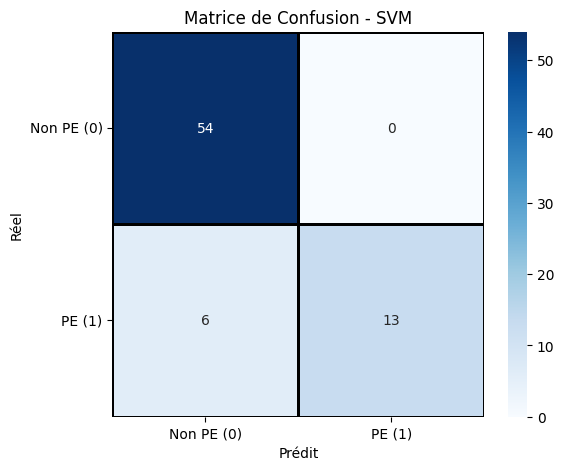

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_excel(r"C:\Users\user\Downloads\preprocessed_preeclampsia 1.xlsx")

df.columns = df.columns.str.strip().str.lower()

# ==============================
# 2. CLEANING
# ==============================
df = df.replace(',', '.', regex=True)

for col in df.columns:
    if df[col].dtype == "object":
        try:
            df[col] = df[col].astype(float)
        except:
            pass

# ==============================
# 3. TARGET
# ==============================
if "category" in df.columns:
    df = df.rename(columns={"category": "target"})
elif "diagnosis" in df.columns:
    df = df.rename(columns={"diagnosis": "target"})

df["target"] = df["target"].astype(int)

# ==============================
# 4. FEATURES / TARGET
# ==============================
X = df.drop(columns=["target", "patient"], errors="ignore")
y = df["target"]

X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.mean())

# ==============================
# 5. SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# 6. SCALING
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 7. GRID SEARCH
# ==============================
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    SVC(class_weight="balanced"),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

model = grid.best_estimator_

print("Best parameters :", grid.best_params_)

# ==============================
# 8. PREDICTIONS
# ==============================
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# ==============================
# 9. ACCURACY
# ==============================
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\nAccuracy TRAIN :", train_acc)
print("Accuracy TEST  :", test_acc)

# ==============================
# 10. CLASSIFICATION REPORT
# ==============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

# ==============================
# 11. MATRICE DE CONFUSION
# ==============================
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black"
)

plt.title("Matrice de Confusion - SVM")
plt.xlabel("Prédit")
plt.ylabel("Réel")

plt.xticks([0.5, 1.5], ["Non PE (0)", "PE (1)"])
plt.yticks([0.5, 1.5], ["Non PE (0)", "PE (1)"], rotation=0)

plt.show()